# Mitsui-style recursive feature forecasting with TFTS

from: https://www.kaggle.com/competitions/mitsui-commodity-prediction-challenge/writeups/artem777-in-mitsui-6th-Place

1. **Recursive full-feature forecasting** — an LSTM reads a window of *all* feature
   columns and predicts the **next single feature row**. That row is fed back into the
   model and the window is re-slid, iterating `MAX_LAG + 1 = 5` times.
2. **Target construction** — each forecasted feature row is turned into the competition
   targets via a lookup table of `(a, b, lag)` pairs, computing the *log-return*
   `log(a_{t+lag}/a_{t+1})` (minus `log(b_{t+lag}/b_{t+1})` when `b` is present).
3. **Label-lag correction** — the model targets are blended with the mean of recent real
   label lags: `corrected = 0.7 * model_targets + 0.3 * lag_mean`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense

from tfts.data import AutoPreprocessor
from tfts.generation import GenerationEngine, MeanSampler, StepOutput
from tfts.models.base import BaseConfig, BaseModel

I0000 00:00:1787851666.923821 1802871 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1787851667.890162 1802871 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Imagine the Mitsui data

Build a synthetic matrix with the same structure as the competition:

- `train`          : one row per `date_id`, one column per feature (424 in the real
                     competition, 20 here). Geometric random walks keep every value
                     strictly positive so the log-return targets are well-defined.
- `target_pairs`   : the `(a, b, lag)` pairs that define the 424 targets. We use a small
                     hand-written subset covering both single-series and spread targets.
- `label_lags`     : the API-provided *recent real* feature rows used by the correction.


In [2]:
rng = np.random.default_rng(42)

FEATURES = 20
N_DAYS = 600
WINDOW_SIZE = 50
MAX_LAG = 4
FORECAST_STEPS = MAX_LAG + 1


def commodity_walk(n, f, scale=0.008):
    t = np.arange(n)
    seasonal = 0.004 * np.sin(t / 17.0 + f) + 0.002 * np.cos(t / 5.0 + f)
    return np.cumsum(seasonal + rng.normal(0.0, scale, n))


feature_names = [f"feature_{i}" for i in range(FEATURES)]
train = pd.DataFrame({name: commodity_walk(N_DAYS, i) for i, name in enumerate(feature_names)})

# (a, b, lag): lag=0 -> return from t+1 to t+1 (b ignored), lag>=1 -> spread log-return.


def _pairs():
    ps = []
    for i in range(8):
        ps.append({"target": i, "lag": int(rng.integers(1, MAX_LAG + 1)), "a": feature_names[i], "b": None})
    for j in range(8, 12):
        ps.append(
            {
                "target": j,
                "lag": int(rng.integers(1, MAX_LAG + 1)),
                "a": feature_names[j],
                "b": feature_names[(j + 3) % FEATURES],
            }
        )
    return ps


target_pairs = _pairs()

# Recent *real* history (the API label lags): last 4 days, slightly corrupted.
label_lags = train.iloc[-WINDOW_SIZE : -WINDOW_SIZE + MAX_LAG + 1].copy()
for _ in range(3):
    label_lags = pd.concat([label_lags, train.iloc[-1:]], ignore_index=True)  # stand-in rows, real API gives 4 batches

train.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19
0,0.004438,0.008570,-0.007775,-0.001733,-0.007903,0.006724,0.008549,-0.002337,0.003869,-0.002671,-0.002053,0.003076,0.006315,0.007994,0.000409,0.001908,-0.003406,-0.013551,-0.001470,-0.005660
1,-0.001687,0.008161,-0.009309,0.000141,-0.004218,0.009400,0.028994,-0.014233,0.011448,0.002663,-0.006278,-0.002956,0.012150,0.019258,0.013544,-0.006367,-0.001288,-0.009318,-0.007165,0.005677
2,0.006628,0.022293,-0.004005,-0.004133,-0.005896,0.022722,0.019205,-0.006067,0.014157,-0.008714,-0.003043,-0.001005,0.016687,0.021529,0.013882,-0.005240,0.002268,-0.017456,-0.012180,0.007525
3,0.016506,0.020907,-0.003250,-0.009343,-0.015140,0.008314,0.032345,0.014512,0.024385,-0.009661,-0.001691,-0.002020,0.017755,0.013829,0.022041,-0.014368,0.000072,-0.040113,-0.017241,0.007663
4,0.003223,0.019137,-0.007190,-0.010560,-0.025446,0.004497,0.034453,0.028995,0.022780,-0.008878,-0.028865,0.001294,0.014205,0.006058,0.026228,-0.005044,0.004784,-0.028990,-0.021340,0.014028


## 2. Preprocess with `AutoPreprocessor`

TFTS `AutoPreprocessor` does the same job as Mitsui's `StandardScaler` +
`fillna`: impute missing values and standardize every feature column. Keep the fitted
preprocessor around so the recursive forecasts can be mapped back to the original scale.


In [3]:
pre = AutoPreprocessor(handle_missing="interpolate", normalize="standard", columns=feature_names)
train_scaled = pre.fit_transform(train)
train_scaled.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19
0,-0.319023,1.036132,1.274213,2.551002,-0.460825,-1.248022,-0.089651,-1.572310,1.957252,-0.015723,0.073631,0.625225,0.813376,-0.906546,-2.260810,1.260276,0.030034,0.422525,-0.858456,-1.271981
1,-0.418798,1.029903,1.261867,2.567615,-0.419338,-1.208361,0.107403,-1.748036,2.032477,0.023654,0.035019,0.543503,0.854430,-0.748973,-2.022789,1.207662,0.051219,0.485170,-0.906838,-1.121269
2,-0.283335,1.245405,1.304568,2.529727,-0.438233,-1.010930,0.013058,-1.627413,2.059358,-0.060343,0.064588,0.569930,0.886356,-0.717211,-2.016669,1.214827,0.086801,0.364741,-0.949438,-1.096702
3,-0.122423,1.224268,1.310650,2.483532,-0.542297,-1.224456,0.139699,-1.323412,2.160871,-0.067332,0.076941,0.556178,0.893865,-0.824915,-1.868814,1.156784,0.064829,0.029474,-0.992436,-1.094865
4,-0.338805,1.197271,1.278928,2.472739,-0.658315,-1.281027,0.160019,-1.109471,2.144942,-0.061554,-0.171401,0.601079,0.868889,-0.933623,-1.792948,1.216073,0.111975,0.194063,-1.027252,-1.010248


## 3. Full-feature LSTM + independent rollout engine

This is the heart of the strategy. Two ingredients:

- A small `BaseModel` whose `__call__` emits the **entire next feature row**
  (dimension `FEATURES`), exactly like Mitsui's `FeatLSTM`.
- A `GenerationEngine` whose feedback function appends the predicted full row to the
  rolling window. The model stays independent from inference policy.


In [4]:
class FullFeatureLSTMConfig(BaseConfig):
    model_type = "full_feature_lstm"

    def __init__(self, hidden_size: int = 64, input_dim: int = FEATURES):
        super().__init__()
        self.hidden_size = hidden_size
        self.input_dim = input_dim


class FullFeatureLSTM(BaseModel):
    "Predict the whole next feature row, then roll it back for the next step."

    def __init__(self, config=None):
        super().__init__(predict_sequence_length=1, config=config or FullFeatureLSTMConfig())
        self.lstm = LSTM(self.config.hidden_size, return_sequences=False)
        self.head = Dense(self.config.input_dim)

    def call(self, inputs, training=None):
        # Emit one full feature row: [batch, 1, FEATURES]. Keeping the horizon axis
        # explicit so an external rollout can append it to the window.
        _, encoder_feature, _ = self._prepare_3d_inputs(inputs)
        hidden = self.lstm(encoder_feature)  # (batch, hidden)
        return self.head(hidden)[:, None, :]  # (batch, 1, FEATURES)

### Train

Mitsui trains the LSTM to predict the whole next feature row (`y = X[t+1]`) from a past
window (`X[t-WINDOW:t]`). This is a plain supervised/teacher-forced fit — the recursion
happens later at inference time via `generate()`.


In [5]:
def prepare_windows(df, window_size):
    X = df.values.astype(np.float32)
    X_wins, y_next = [], []
    for i in range(len(X) - window_size):
        X_wins.append(X[i : i + window_size])
        y_next.append(X[i + window_size])
    return np.stack(X_wins), np.stack(y_next)


X_wins, y_next = prepare_windows(train_scaled, WINDOW_SIZE)
N = len(X_wins)
val_size = int(0.15 * N)
X_train, y_train = X_wins[:-val_size], y_next[:-val_size]
X_val, y_val = X_wins[-val_size:], y_next[-val_size:]
y_train = y_train[:, None, :]  # (N, 1, FEATURES) -- model emits one full next row
y_val = y_val[:, None, :]
print("train windows:", X_train.shape, "target row:", y_train.shape)

model = FullFeatureLSTM(FullFeatureLSTMConfig(hidden_size=64, input_dim=FEATURES))

keras_model = model.build_model(tf.keras.Input(shape=(WINDOW_SIZE, FEATURES)))
keras_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

history = keras_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=15,
    verbose=1,
)

train windows: (468, 50, 20) target row: (468, 1, 20)


Epoch 1/15


1/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - loss: 0.8683

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.7657 - val_loss: 1.1594


Epoch 2/15


...

1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0312

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0291 - val_loss: 0.4965


Epoch 15/15


1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0270

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0270 - val_loss: 0.4972


## 4. Recursive multi-day forecast

Initialize the rolling window with the most recent observed (scaled) `WINDOW_SIZE` rows,
then ask the model to generate `FORECAST_STEPS` future *full feature rows* one day at a
time. This is the exact recursion of Mitsui's
`forecast_next_days_from_history`: predict a row, feed it back, re-slide the window.

Back-transform the generated rows to the original scale with the fitted
`AutoPreprocessor` before computing the targets.


In [6]:
history_window = train_scaled.values[-WINDOW_SIZE:][None, ...].astype(np.float32)  # (1, WINDOW, FEATURES)


def step_fn(current, state, step):
    return StepOutput(prediction=model(current, training=False), state=state)


def feedback(current, result, **kwargs):
    return tf.concat([current[:, 1:, :], result.value], axis=1)


out = GenerationEngine(MeanSampler(), feedback).run(step_fn, history_window, initial_state=None, horizon=FORECAST_STEPS)

feat_scaled = out.values[0].numpy()  # (FORECAST_STEPS, FEATURES)
feat_forecast = pre.inverse_transform(pd.DataFrame(feat_scaled, columns=feature_names)).values
print("forecasted feature rows:", feat_forecast.shape)
feat_forecast

forecasted feature rows: (5, 20)


array([[ 0.01845418, -0.04099896, -0.35609704, -0.37395   ,  0.09780072,
         0.13882373, -0.02308284,  0.04565275, -0.1910498 ,  0.16916847,
         0.17667297,  0.05699059, -0.17539036,  0.08552991,  0.10200238,
        -0.43089664, -0.09244613,  0.08003492,  0.0985653 ,  0.11046252],
       [ 0.01540046, -0.04355181, -0.36917385, -0.36475775,  0.09735742,
         0.14723131, -0.02753874,  0.04338174, -0.20486799,  0.17751464,
         0.18600209,  0.06711572, -0.20252265,  0.08962122,  0.09766725,
        -0.41290843, -0.09501091,  0.08634044,  0.09550587,  0.11240967],
       [ 0.01255436, -0.04860521, -0.37546593, -0.36306497,  0.10242759,
         0.15104468, -0.04004157,  0.04062904, -0.20900933,  0.1828534 ,
         0.19192891,  0.07080812, -0.21058612,  0.08992624,  0.09856905,
        -0.41510746, -0.09718142,  0.09296648,  0.09881023,  0.10950162],
       [ 0.00950556, -0.05279512, -0.37934244, -0.36090857,  0.10639612,
         0.15479887, -0.04919539,  0.03834315, -

## 5. From feature forecasts to competition targets

Replicate `compute_targets_from_feature_forecasts`: for each `(a, b, lag)` pair, take
the forecasted row at `t+1` and at `t+lag`, and form the (spread) log-return.


In [7]:
def compute_targets(forecasts, pairs, cols):
    idx = {c: i for i, c in enumerate(cols)}
    results = []
    for p in pairs:
        a, b, lag = p["a"], p["b"], p["lag"]
        if a not in idx:
            results.append(0.0)
            continue
        a_t1 = max(forecasts[0][idx[a]], 1e-9)
        a_tlag = max(forecasts[min(lag, len(forecasts) - 1)][idx[a]], 1e-9)
        a_ret = np.log(a_tlag / a_t1)
        if b is None or b not in idx:
            results.append(a_ret)
        else:
            b_t1 = max(forecasts[0][idx[b]], 1e-9)
            b_tlag = max(forecasts[min(lag, len(forecasts) - 1)][idx[b]], 1e-9)
            results.append(a_ret - np.log(b_tlag / b_t1))
    return np.array(results, dtype=np.float32)


model_targets = compute_targets(feat_forecast, target_pairs, feature_names)
print("raw model targets:", np.round(model_targets, 4))

raw model targets: [-0.6634  0.      0.      0.     -0.0045  0.0588  0.     -0.1745 -0.1635
  0.1389  0.0047  0.3069]


## 6. Label-lag correction (0.7 / 0.3 blend)

Finally blunt the model's drift away from the current market state by blending with the
mean of the recent real label lags, exactly as Mitsui does:

```python
corrected = alpha * model_targets + (1 - alpha) * correction
alpha = 0.7
```

The "correction" for a pair is the recent-observed mean of `a - b` (falling back to `a`
or `-b` if one series is missing), built from the API-provided `label_lags` batches.


In [8]:
alpha = 0.7

# Mean of the recent real feature rows, indexed by feature name (like Mitsui's lag_mean).
lag_mean = label_lags.mean(axis=0).fillna(0.0)

results = pd.DataFrame(
    {
        "a": [p["a"] for p in target_pairs],
        "b": [p["b"] for p in target_pairs],
        "lag": [p["lag"] for p in target_pairs],
        "model": model_targets,
        "lag_mean": [lag_mean[p["a"]] - (lag_mean[p["b"]] if p["b"] in lag_mean else 0.0) for p in target_pairs],
    }
)
results["corrected"] = alpha * results["model"] + (1 - alpha) * results["lag_mean"]
results

,a,b,lag,model,lag_mean,corrected
0,feature_0,NaN,3,-0.663414,-0.015319,-0.468985
1,feature_1,NaN,2,0.000000,-0.015141,-0.004542
2,feature_2,NaN,3,0.000000,-0.381371,-0.114411
3,feature_3,NaN,3,0.000000,-0.265908,-0.079772
4,feature_4,NaN,1,-0.004543,0.113621,0.030906
5,feature_5,NaN,1,0.058800,0.126911,0.079233
6,feature_6,NaN,2,0.000000,-0.075453,-0.022636
7,feature_7,NaN,3,-0.174488,0.033285,-0.112156
8,feature_8,feature_11,1,-0.163532,-0.122278,-0.151156
9,feature_9,feature_12,4,0.138854,0.590041,0.274210


## 7. Sanity check

A corrected target should sit between the raw model target and the lag-mean anchor —
i.e. it dampens large model swings towards the recent market state, which is precisely
the intended effect during turbulent periods.


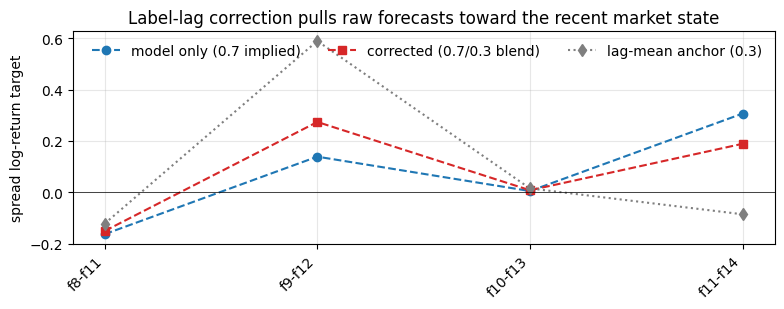

In [9]:
spreads = results.iloc[8:]  # the (a - b) spread targets, where the shift is most visible
fig, ax = plt.subplots(figsize=(8, 3.2))

x = np.arange(len(spreads))
ax.plot(x, spreads["model"], "o--", color="#1f77b4", label="model only (0.7 implied)")
ax.plot(x, spreads["corrected"], "s--", color="#d62728", label="corrected (0.7/0.3 blend)")
ax.plot(x, spreads["lag_mean"], "d:", color="#7f7f7f", label="lag-mean anchor (0.3)")
ax.axhline(0.0, color="k", lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(
    [f'{r["a"].replace("feature_", "f")}-{r["b"].replace("feature_", "f")}' for _, r in spreads.iterrows()],
    rotation=45,
    ha="right",
)
ax.set_ylabel("spread log-return target")
ax.set_title("Label-lag correction pulls raw forecasts toward the recent market state")
ax.legend(frameon=False, ncol=3)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()